# Employee Attrition Risk: Drivers and Retention Prioritization

### Question
Which workplace, career and AI-related factors are associated with employee attrition, and how well can a risk score help HR focus limited retention effort on employees at greater risk of leaving?

### Data
5,000 employee records across 8 departments and 25 job roles, with an overall attrition rate of 17.9%. Each record combines standard HR variables (tenure, promotion history, pay, job level, work mode) with survey-style wellbeing scores (burnout, engagement, manager support, work-life balance), weekly overtime, AI tool usage and a self-reported perceived AI job risk rating.

*Source:* course-provided dataset. Its original generation process and external provenance are not documented in the supplied materials, so the results describe patterns in this dataset and should not be read as evidence about any real organization.

### Structure
1. **Data quality:** missing values, duplicates, ranges, logical consistency, class balance
2. **Where attrition concentrates:** department, job role, work mode
3. **Wellbeing drivers:** leaver vs stayer gaps ranked by Cohen's d
4. **AI risk perception:** attrition by AI-risk band, AI tool usage, department positioning
5. **Demographic and career-stage patterns:** age, tenure, job level, promotion timing, pay
6. **Multivariable logistic regression:** nested models, odds ratios with confidence intervals, likelihood-ratio tests
7. **Out-of-sample risk scoring:** cross-validated risk ranking, calibration, lift, comparison with a rule-based watch list
8. **Key findings and recommendations**

### Methods
pandas and NumPy for data preparation; Cohen's d for effect sizes; logistic regression with odds ratios, 95% confidence intervals and likelihood-ratio tests (statsmodels); stratified 5-fold cross-validation, ROC-AUC, PR-AUC, Brier score and calibration (scikit-learn); risk deciles, lift and recall with bootstrap confidence intervals; Matplotlib for visualization.

Gender, age, marital status and education are described in Section 5 but are not used to score individual employees.

## 1. Data Understanding & Quality Assessment

### 1.1 Load the dataset and inspect its structure

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)   
pd.set_option('display.width', 200)      

df = pd.read_csv('employee_attrition_hr_2026.csv')
df.shape 

(5000, 29)

In [2]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   employee_id                    5000 non-null   int64  
 1   age                            5000 non-null   int64  
 2   gender                         5000 non-null   str    
 3   marital_status                 5000 non-null   str    
 4   education_level                5000 non-null   str    
 5   department                     5000 non-null   str    
 6   job_role                       5000 non-null   str    
 7   job_level                      5000 non-null   int64  
 8   monthly_income                 5000 non-null   int64  
 9   stock_option_level             5000 non-null   int64  
 10  salary_hike_pct                5000 non-null   float64
 11  years_at_company               5000 non-null   float64
 12  total_working_years            5000 non-null   float64
 13 

### 1.2 Missing Values & Duplicates

In [3]:
missing = df.isnull().sum()
missing = missing[missing > 0]  
print("Columns with missing values:")
print(missing)
print("\nTotal missing cells:", df.isnull().sum().sum())

Columns with missing values:
Series([], dtype: int64)

Total missing cells: 0


In [4]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate employee_id:", df['employee_id'].duplicated().sum())
print("employee_id range:", df['employee_id'].min(), "-", df['employee_id'].max())
print("Unique employee_id count:", df['employee_id'].nunique())

Fully duplicated rows: 0
Duplicate employee_id: 0
employee_id range: 1001 - 6000
Unique employee_id count: 5000


**Finding:** No missing values and no duplicate rows were found. employee_id has no duplicates. 

### 1.3 Attrition Class Balance

In [5]:
attrition_counts = df['attrition'].value_counts()               # count per class 
attrition_pct = df['attrition'].value_counts(normalize=True) * 100  # percentage

pd.DataFrame({'count': attrition_counts, 'pct(%)': attrition_pct.round(1)})

,count,pct(%)
attrition,,
No,4105,82.1
Yes,895,17.9


### 1.4 Variable Scale & Range Check

In [6]:
num_cols = ['age','monthly_income','salary_hike_pct','years_at_company','total_working_years',
            'years_since_promotion','num_prior_companies','commute_minutes','overtime_hours_per_week',
            'business_travel_days_per_year','training_hours','manager_support_score','burnout_score',
            'engagement_score','work_life_balance_score','last_review_score','perceived_ai_job_risk']

df[num_cols].describe().T   # count/mean/std/min/25%/50%/75%/max for each variable
                            

,count,mean,std,min,25%,50%,75%,max
age,5000.0,37.11980,8.234161,21.0,31.000,37.0,43.00,64.0
monthly_income,5000.0,6990.71980,2701.899360,1500.0,4971.000,6569.0,8604.25,21609.0
salary_hike_pct,5000.0,11.51820,3.408021,0.0,9.300,11.6,13.80,22.6
years_at_company,5000.0,6.72462,3.500219,0.0,4.275,6.8,9.20,18.1
total_working_years,5000.0,11.69926,4.995870,0.0,8.300,11.9,15.10,30.4
years_since_promotion,5000.0,1.97190,1.628239,0.0,0.800,1.6,2.80,11.1
num_prior_companies,5000.0,1.80520,1.345665,0.0,1.000,2.0,3.00,8.0
commute_minutes,5000.0,31.16020,19.435073,0.0,14.000,33.0,46.00,92.0
overtime_hours_per_week,5000.0,6.82822,4.470515,0.0,3.600,5.9,9.00,34.9
business_travel_days_per_year,5000.0,10.81900,8.092227,0.0,5.000,7.0,18.00,38.0


In [7]:
# check the 1-10 scales
for c in ['manager_support_score','burnout_score','engagement_score',
          'work_life_balance_score','perceived_ai_job_risk']:
    print(c, "min:", df[c].min(), "max:", df[c].max())

# check monthly income range
print("monthly_income range:", df['monthly_income'].min(), "-", df['monthly_income'].max())

manager_support_score min: 1.0 max: 10.0
burnout_score min: 1.0 max: 10.0
engagement_score min: 1.0 max: 10.0
work_life_balance_score min: 1.0 max: 9.9
perceived_ai_job_risk min: 1.0 max: 10.0
monthly_income range: 1500 - 21609


**Finding:** monthly_income ranges from $1,500 to $21,609, a plausible range for monthly pay. All wellbeing and AI-risk scores fall within 1–10, though work_life_balance_score tops out at 9.9 

### 1.5 Categorical Variables Overview
Numeric variables were summarized above. The categorical variables are checked here to complete the overview.

In [8]:
cat_cols = ['gender','marital_status','education_level','department','job_role','work_mode','attrition']
for c in cat_cols:
    print(f"{c}: {df[c].nunique()} categories")

gender: 4 categories
marital_status: 3 categories
education_level: 4 categories
department: 8 categories
job_role: 25 categories
work_mode: 3 categories
attrition: 2 categories


In [9]:
# look at the actual distribution, not just the count of categories
print(df['department'].value_counts(), "\n")
print(df['work_mode'].value_counts(), "\n")
print(df['gender'].value_counts(), "\n")
print(df['marital_status'].value_counts(), "\n")
print(df['education_level'].value_counts())

department
Engineering               1336
Sales                      835
Operations                 663
Customer Support           636
Marketing                  440
Finance                    436
Research & Development     410
Human Resources            244
Name: count, dtype: int64 

work_mode
Hybrid    2237
Onsite    1742
Remote    1021
Name: count, dtype: int64 

gender
Male                 2492
Female               2310
Non-binary            100
Prefer not to say      98
Name: count, dtype: int64 

marital_status
Married     2387
Single      2070
Divorced     543
Name: count, dtype: int64 

education_level
Bachelors      2562
Masters        1534
High School     512
PhD             392
Name: count, dtype: int64


**Finding:** department has 8 categories, job_role has 25, and work_mode has 3. gender actually has 4 categories (not binary); Non-binary (100) and Prefer not to say (98) are small subgroups that will need cautious interpretation in later demographic analysis.

### 1.6 Logical Consistency Check
Before finalizing data quality, check whether related numeric fields are internally
consistent 

In [10]:
inconsistent = df[df['years_at_company'] > df['total_working_years']]
print(f"Rows with years_at_company > total_working_years: {len(inconsistent)} "
      f"({len(inconsistent)/len(df)*100:.2f}% of dataset)")

diff = inconsistent['years_at_company'] - inconsistent['total_working_years']
print("\nSize of discrepancy (years):")
print(diff.describe()[['mean','min','max']])

print("\nAttrition rate in this subset vs overall:")
print(f"  subset:  {inconsistent['attrition'].eq('Yes').mean()*100:.1f}%")
print(f"  overall: {df['attrition'].eq('Yes').mean()*100:.1f}%")

Rows with years_at_company > total_working_years: 59 (1.18% of dataset)

Size of discrepancy (years):
mean    0.767797
min     0.100000
max     3.500000
dtype: float64

Attrition rate in this subset vs overall:
  subset:  15.3%
  overall: 17.9%


**Finding:** 59 rows (1.18%) show years_at_company > total_working_years, with a small discrepancy (mean 0.77 years). Attrition rate in this subset (15.3%) is close to the overall rate (17.9%), suggesting this is data-generation noise rather than a systematic error.

**Decision:** These rows are flagged, not removed.

In [11]:
df_clean = df.copy()

# Flag the 59 logically-inconsistent rows found in 1.6 (not deleted)
df_clean['data_flag'] = np.where(
    df_clean['years_at_company'] > df_clean['total_working_years'],
    'tenure_inconsistency', 'ok'
)

df_clean.to_csv('employee_attrition_cleaned.csv', index=False)

print("Cleaned dataset saved. Shape:", df_clean.shape)
print(df_clean['data_flag'].value_counts())

Cleaned dataset saved. Shape: (5000, 30)
data_flag
ok                      4941
tenure_inconsistency      59
Name: count, dtype: int64


**Class-Imbalance Implications for Later Analysis:**

The attrition target is imbalanced (82.1% No / 17.9% Yes), meaning "Yes"
(attrition) is the minority class. This has several implications for how
the later sections are conducted:

1. **Department/role/work-mode ranking (Section 2):** Comparisons must be
   based on attrition **rate**, not raw headcount. Since leavers are a
   minority overall, larger groups will naturally have more leavers in
   absolute terms without necessarily having a higher underlying risk.

2. **Subgroup comparisons (Sections 3 to 5):** When attrition is broken down
   further by department, role, or demographic segment, some subgroups
   may contain very few "Yes" cases. Attrition rates calculated on small
   subgroups are less statistically reliable and should be flagged
   accordingly rather than treated with the same confidence as larger
   groups.

3. **Risk scoring (Section 7):** Overall accuracy would be a misleading
   metric, since a model that predicts "No" for every employee would already
   achieve roughly 82% accuracy without identifying any actual leavers.
   Section 7 therefore evaluates ranking quality (ROC-AUC, PR-AUC, lift and
   recall among the highest-risk employees) and calibration.


## 2. Attrition Overview by Department, Role & Work Mode

### 2.1 Overall Attrition Rate
As shown in Section 1, the overall attrition rate is 17.9% (895 out of 5,000
employees). This serves as the baseline for comparing department/role/work-mode
level rates below.

### 2.2 Attrition Rate by Department

In [12]:
dept_attrition = df.groupby('department')['attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1)

dept_count = df.groupby('department').size()

dept_summary = pd.DataFrame({
    'attrition_rate(%)': dept_attrition,
    'headcount': dept_count
})

dept_summary = dept_summary.sort_values('attrition_rate(%)', ascending=False)
dept_summary

,attrition_rate(%),headcount
department,,
Customer Support,24.1,636
Sales,20.0,835
Marketing,18.9,440
Finance,18.1,436
Human Resources,18.0,244
Operations,17.2,663
Research & Development,14.9,410
Engineering,14.5,1336


**Finding:** Customer Support (24.1%) and Sales (20.0%) are above the 17.9%
baseline; Engineering (14.5%) and R&D (14.9%) are the lowest. All groups
have sufficient headcount (≥244), so rates are reliable.

### 2.3 job_role
job_role has 25 categories, so sample size per role varies. Attrition rates
for roles with very few employees should be interpreted cautiously.

In [13]:
role_attrition = df.groupby('job_role')['attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1)

role_count = df.groupby('job_role').size()

role_summary = pd.DataFrame({
    'attrition_rate(%)': role_attrition,
    'headcount': role_count
})

role_summary = role_summary.sort_values('attrition_rate(%)', ascending=False)
role_summary

,attrition_rate(%),headcount
job_role,,
Support Team Lead,26.0,204
Support Specialist,25.2,218
Content Strategist,23.9,138
Account Executive,23.8,277
Recruiter,23.2,69
Customer Success Manager,21.0,214
Finance Manager,20.9,139
Sales Development Rep,20.1,259
Growth Manager,19.9,156


**Finding:** Support Team Lead (26.0%), Support Specialist (25.2%), and
Account Executive (23.8%) top the list, mostly support/customer-facing
roles. R&D Manager (10.0%) is lowest. Recruiter (69) and HR Manager (94)
have smaller headcounts, so their rates should be read with some caution.

### 2.4 Attrition Rate by Work Mode

In [14]:
mode_attrition = df.groupby('work_mode')['attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1)

mode_count = df.groupby('work_mode').size()

mode_summary = pd.DataFrame({
    'attrition_rate(%)': mode_attrition,
    'headcount': mode_count
})

mode_summary = mode_summary.sort_values('attrition_rate(%)', ascending=False)
mode_summary

,attrition_rate(%),headcount
work_mode,,
Onsite,21.2,1742
Hybrid,16.8,2237
Remote,14.7,1021


**Finding:** Attrition decreases as flexibility increases: Onsite (21.2%),
Hybrid (16.8%), Remote (14.7%). Sample sizes are all large (1,000+),
so the comparison is reliable.

### Summary of Where Attrition Concentrates Today

Attrition today is concentrated in customer-facing and support-oriented
roles, not spread evenly across the company. At the department level,
Customer Support has the highest attrition rate at 24.1%, followed by
Sales at 20.0%, and both are clearly above the 17.9% company-wide baseline.
Engineering and R&D, on the other hand, sit below the baseline even though
Engineering is the largest department in the company. This pattern also
shows up at the job role level. The three roles with the highest attrition
are Support Team Lead (26.0%), Support Specialist (25.2%), and Account
Executive (23.8%), and all three are customer or support facing positions.
This means the department level finding is not caused by just one or two
roles, but reflects a broader problem across the whole support function.

Work mode adds another layer to this picture. Attrition decreases as work
flexibility increases, going from Onsite at 21.2%, to Hybrid at 16.8%, to
Remote at 14.7%. Putting all three findings together, the group most at
risk of leaving right now is onsite employees working in customer support
roles, and this group should be treated as a priority when building the
retention watch list in Section 7.

## 3. Workplace Wellbeing Drivers of Attrition

### 3.1 Leavers vs Stayers: Mean Comparison

In [15]:
metrics = ['burnout_score', 'engagement_score', 'work_life_balance_score',
           'manager_support_score', 'overtime_hours_per_week']

# group by attrition, get mean of each metric, then transpose so metrics are rows
comparison = df.groupby('attrition')[metrics].mean().round(2).T
comparison.columns = ['Stayed (No)', 'Left (Yes)']
comparison['Difference (Left - Stayed)'] = (
    comparison['Left (Yes)'] - comparison['Stayed (No)']
).round(2)

comparison

,Stayed (No),Left (Yes),Difference (Left - Stayed)
burnout_score,3.81,5.06,1.25
engagement_score,6.72,5.54,-1.18
work_life_balance_score,6.25,5.57,-0.68
manager_support_score,6.81,5.69,-1.12
overtime_hours_per_week,6.40,8.77,2.37


### 3.2 Rank by Separation Strength (Cohen's d)

In [16]:
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std

effect_sizes = {}
for m in metrics:
    left = df[df['attrition'] == 'Yes'][m]
    stayed = df[df['attrition'] == 'No'][m]
    effect_sizes[m] = cohens_d(left, stayed)

effect_df = pd.DataFrame.from_dict(effect_sizes, orient='index', columns=["Cohen's d"])
effect_df['abs_d'] = effect_df["Cohen's d"].abs()
effect_df = effect_df.sort_values('abs_d', ascending=False).round(3)
effect_df

,Cohen's d,abs_d
burnout_score,0.854,0.854
engagement_score,-0.828,0.828
manager_support_score,-0.630,0.630
overtime_hours_per_week,0.541,0.541
work_life_balance_score,-0.537,0.537


**Finding:** Burnout (d=0.854) and engagement (d=-0.828) are the strongest
drivers, ranking above overtime (d=0.541) even though overtime had the
largest raw difference in 3.1. Standardizing the scores changes the ranking.

### 3.3 Flag Counterintuitive Patterns
**Finding:** All five metrics moved in the expected direction, no
counterintuitive patterns found.

## 4. AI Risk Perception vs Attrition Alignment

### 4.1 Attrition Rate by AI Risk Band
perceived_ai_job_risk is split into three equal-sized bands (Low/Medium/High)
using tertiles, so each band has a comparable sample size.

In [17]:
df['ai_risk_band'] = pd.qcut(df['perceived_ai_job_risk'], q=3, labels=['Low', 'Medium', 'High'])

band_attrition = df.groupby('ai_risk_band')['attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1)
band_count = df.groupby('ai_risk_band',observed=True).size()

band_summary = pd.DataFrame({
    'attrition_rate(%)': band_attrition,
    'headcount': band_count
})
band_summary

,attrition_rate(%),headcount
ai_risk_band,,
Low,13.8,1733
Medium,17.9,1669
High,22.3,1598


### 4.2 Attrition Rate by AI Tool Usage

In [18]:
tool_attrition = df.groupby('uses_ai_tools_at_work')['attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1)
tool_count = df.groupby('uses_ai_tools_at_work').size()

tool_summary = pd.DataFrame({
    'attrition_rate(%)': tool_attrition,
    'headcount': tool_count
})
tool_summary

,attrition_rate(%),headcount
uses_ai_tools_at_work,,
False,18.6,2135
True,17.3,2865


**Finding:** Attrition rises steadily with perceived AI risk, from 13.8%
(Low) to 22.3% (High), an 8.5-point gap. In contrast, uses_ai_tools_at_work
shows almost no difference (18.6% vs 17.3%). Attrition is therefore
associated with employees' subjective sense of AI threat rather than with
whether they actually use AI tools day to day.

### 4.3 First Look: AI Risk Alongside Burnout & Engagement

In [19]:
import statsmodels.api as sm

# prepare predictors: burnout, engagement, and AI risk perception
X = df[['burnout_score', 'engagement_score', 'perceived_ai_job_risk']].copy()

# target variable: 1 = left, 0 = stayed
y = (df['attrition'] == 'Yes').astype(int)

# standardize predictors so coefficients are comparable across different scales
X_scaled = (X - X.mean()) / X.std()
X_scaled = sm.add_constant(X_scaled)   # add intercept term

# fit logistic regression
model = sm.Logit(y, X_scaled).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.405160
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              attrition   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4996
Method:                           MLE   Df Model:                            3
Date:                Tue, 06 Oct 2026   Pseudo R-squ.:                  0.1377
Time:                        21:01:34   Log-Likelihood:                -2025.8
converged:                       True   LL-Null:                       -2349.4
Covariance Type:            nonrobust   LLR p-value:                6.081e-140
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.8185      0.046    -39.554      0.000      -1.909      -1.

**Finding:** After controlling for burnout and engagement in a logistic
regression, perceived_ai_job_risk remains statistically significant
(coef=0.171, p<0.001), so it is not simply a proxy for burnout or low
engagement. Its coefficient is about a third the size of burnout (0.551)
and engagement (-0.573). This model controls for only two factors, and
AI risk also differs strongly by department, so Section 6 re-tests it with
the full set of wellbeing, career and department controls.

### 4.4 Department Quadrant Classification

In [20]:
# calculate average AI risk perception and attrition rate per department
dept_quad = df.groupby('department').agg(
    avg_ai_risk=('perceived_ai_job_risk', 'mean'),
    attrition_rate=('attrition', lambda x: (x == 'Yes').mean() * 100),
    headcount=('attrition', 'size')
).round(2)

# use the median across departments as the split point for each axis
ai_risk_median = dept_quad['avg_ai_risk'].median()
attrition_median = dept_quad['attrition_rate'].median()

def classify(row):
    high_ai = row['avg_ai_risk'] >= ai_risk_median
    high_attr = row['attrition_rate'] >= attrition_median
    if high_ai and high_attr:
        return 'AI-Risk-Driven'
    elif not high_ai and high_attr:
        return 'Wellbeing-Driven'
    elif high_ai and not high_attr:
        return 'Mixed (High AI risk, Low attrition)'
    else:
        return 'Low Concern'

dept_quad['segment'] = dept_quad.apply(classify, axis=1)
dept_quad = dept_quad.sort_values('attrition_rate', ascending=False)
dept_quad

,avg_ai_risk,attrition_rate,headcount,segment
department,,,,
Customer Support,6.30,24.06,636,AI-Risk-Driven
Sales,5.19,20.00,835,AI-Risk-Driven
Marketing,5.49,18.86,440,AI-Risk-Driven
Finance,5.47,18.12,436,AI-Risk-Driven
Human Resources,4.73,18.03,244,Low Concern
Operations,4.93,17.19,663,Low Concern
Research & Development,3.69,14.88,410,Low Concern
Engineering,3.90,14.52,1336,Low Concern


**Finding:** All 8 departments fall into only two segments,
AI-Risk-Driven (Customer Support, Sales, Marketing, Finance) and
Low Concern (HR, Operations, R&D, Engineering). No departments fall into
Wellbeing-Driven or Mixed. This is because AI risk perception and
attrition rate rank almost identically at the department level, and the four
departments with the highest AI risk are also the four with the highest
attrition, led by Customer Support (highest on both: AI risk 6.30,
attrition 24.06%).

## 5. Demographic & Career-Stage Comparison

### 5.1 Attrition by Age Band

In [21]:
df['age_band'] = pd.cut(df['age'], bins=[20, 30, 40, 50, 65],
                         labels=['21-30', '31-40', '41-50', '51-64'])

age_summary = df.groupby('age_band', observed=True)['attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1)
age_count = df.groupby('age_band', observed=True).size()

pd.DataFrame({'attrition_rate(%)': age_summary, 'headcount': age_count})

,attrition_rate(%),headcount
age_band,,
21-30,18.3,1082
31-40,18.4,2208
41-50,17.5,1416
51-64,14.6,294


**Finding:** Attrition is fairly flat across ages 21-50 (17.5%-18.4%,
close to the 17.9% baseline), with no clear age-based gradient in this
range. Only the oldest group (51-64) stands out with a notably lower rate
(14.6%)

### 5.2 Attrition by Tenure (Years at Company)

In [22]:
df['tenure_band'] = pd.cut(df['years_at_company'], bins=[-0.1, 2, 5, 10, 20],
                            labels=['0-2 yrs', '2-5 yrs', '5-10 yrs', '10+ yrs'])

tenure_summary = df.groupby('tenure_band', observed=True)['attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1)
tenure_count = df.groupby('tenure_band', observed=True).size()

pd.DataFrame({'attrition_rate(%)': tenure_summary, 'headcount': tenure_count})

,attrition_rate(%),headcount
tenure_band,,
0-2 yrs,18.4,553
2-5 yrs,20.9,1078
5-10 yrs,17.4,2500
10+ yrs,15.2,869


**Finding:** Attrition doesn't decline monotonically with tenure. The
2-5 year group has the highest rate (20.9%), even higher than brand-new
employees (0-2 yrs: 18.4%). It then drops steadily at 5-10 yrs (17.4%)
and 10+ yrs (15.2%).

### 5.3 Attrition by Job Level 

In [23]:
level_summary = df.groupby('job_level')['attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1)
level_count = df.groupby('job_level').size()

pd.DataFrame({'attrition_rate(%)': level_summary, 'headcount': level_count})

,attrition_rate(%),headcount
job_level,,
1,20.8,601
2,19.4,1378
3,16.6,1444
4,17.6,948
5,15.3,629


**Finding:** Attrition generally decreases with job level, from 20.8%
(Level 1) to 15.3% (Level 5), though not strictly monotonic: Level 4
(17.6%) is slightly higher than Level 3 (16.6%).


### 5.4 Attrition by Years Since Promotion

In [24]:
df['promo_band'] = pd.cut(df['years_since_promotion'], bins=[-0.1, 1, 2, 4, 12],
                           labels=['0-1 yrs', '1-2 yrs', '2-4 yrs', '4+ yrs'])

promo_summary = df.groupby('promo_band', observed=True)['attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1)
promo_count = df.groupby('promo_band', observed=True).size()

pd.DataFrame({'attrition_rate(%)': promo_summary, 'headcount': promo_count})

,attrition_rate(%),headcount
promo_band,,
0-1 yrs,14.2,1709
1-2 yrs,15.6,1348
2-4 yrs,21.2,1403
4+ yrs,27.0,540


**Finding:** Attrition rises steadily and monotonically with time since
last promotion, from 14.2% (0-1 yrs) to 27.0% (4+ yrs), a 12.8-point
gap. This is the clearest gradient among the career-stage comparisons.

### 5.5 Attrition by Education Level & Marital Status

In [25]:
edu_summary = df.groupby('education_level')['attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1)
edu_count = df.groupby('education_level').size()
edu_table = pd.DataFrame({'attrition_rate(%)': edu_summary, 'headcount': edu_count}).sort_values('attrition_rate(%)', ascending=False)
print("By Education Level:")
print(edu_table)

marital_summary = df.groupby('marital_status')['attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1)
marital_count = df.groupby('marital_status').size()
marital_table = pd.DataFrame({'attrition_rate(%)': marital_summary, 'headcount': marital_count}).sort_values('attrition_rate(%)', ascending=False)
print("\nBy Marital Status:")
print(marital_table)

By Education Level:
                 attrition_rate(%)  headcount
education_level                              
Bachelors                     18.5       2562
High School                   18.4        512
PhD                           17.9        392
Masters                       16.8       1534

By Marital Status:
                attrition_rate(%)  headcount
marital_status                              
Divorced                     18.6        543
Married                      18.0       2387
Single                       17.6       2070


**Finding:** Neither education level nor marital status shows a strong
relationship with attrition. Rates cluster close to the 17.9% baseline
across all categories: education spans 16.8%-18.5% and marital status
spans 17.6%-18.6%, both narrow ranges with no clear pattern.

### 5.6 Whether Compensation Offset Other Risk Factors? 
Using years_since_promotion (the strongest driver found in 5.4) as the
risk factor: within the highest-risk group (4+ years since promotion),
compare attrition between high and low income.

In [26]:
high_risk = df[df['promo_band'] == '4+ yrs'].copy()

income_median = df['monthly_income'].median()
high_risk['income_level'] = np.where(high_risk['monthly_income'] >= income_median,
                                       'High Income', 'Low Income')

offset_check = high_risk.groupby('income_level')['attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1)
offset_count = high_risk.groupby('income_level').size()

pd.DataFrame({'attrition_rate(%)': offset_check, 'headcount': offset_count})

,attrition_rate(%),headcount
income_level,,
High Income,27.3,337
Low Income,26.6,203


**Summary:** Career-stage factors matter more than demographics. Years
since promotion shows the strongest gradient (14.2% to 27.0%), job level
and tenure also relate to attrition (tenure peaks at 2-5 yrs). Age, education,
and marital status show no meaningful pattern.

**Notes:** For the highest-risk segment (4+ years since promotion),
compensation does not retain. High Income employees (27.3%) and
Low Income employees (26.6%) have nearly identical attrition rates,
both far above the 17.9% baseline. This suggests that for employees who
feel stuck in their career progression, pay alone is not an effective
retention lever; the underlying issue is more likely tied to growth
and advancement rather than compensation. This subgroup comparison is
tested more formally across all employees in Section 6.6.

## 6. Multivariable Logistic Regression

Sections 3 to 5 compare leavers and stayers one factor at a time. Many of those factors move together (burnout with overtime, AI risk with department), so a single-factor gap can partly reflect other variables. A multivariable logistic regression estimates each factor's association with attrition while holding the others constant.

### 6.1 Model design

**Outcome.** `attrition = Yes` coded as 1. The model estimates the log-odds of leaving.

**Predictor groups**, added in three nested steps:

| Model | Adds | Variables |
|---|---|---|
| M1 | Wellbeing and workload | burnout, engagement, manager support, work-life balance, overtime |
| M2 | Career and job context | years since promotion, tenure, monthly income, job level, department, work mode |
| M3 | AI variables | perceived AI job risk, uses AI tools at work |

Fitting the groups in sequence answers a specific question from Section 4: **does perceived AI job risk add information once the traditional attrition drivers are already in the model?**

**Excluded variables.** Gender, age, marital status and education are not used as predictors. Section 5 showed they have little association with attrition, and because the model in Section 7 assigns a risk score to individual employees, using protected or closely related personal characteristics would raise fairness concerns. Total working years is also excluded because it is largely a function of age.

**Scaling.** Continuous predictors are standardized, so each odds ratio (OR) describes the change in the odds of leaving for a one standard deviation increase. The table reports what one SD equals in natural units. `uses_ai_tools` is binary (1 = uses AI tools). Reference categories are Customer Support for department and Hybrid for work mode.

In [27]:
import statsmodels.formula.api as smf
from scipy import stats

WELLBEING = ["burnout_score", "engagement_score", "manager_support_score", "work_life_balance_score", "overtime_hours_per_week"]
CAREER = ["years_since_promotion", "years_at_company", "monthly_income", "job_level"]
AI_VARS = ["perceived_ai_job_risk", "uses_ai_tools"]
CONTINUOUS = WELLBEING + CAREER + ["perceived_ai_job_risk"]

# Modeling frame built from the original columns only
mdf = df[WELLBEING + CAREER + ["perceived_ai_job_risk", "department", "job_role", "work_mode"]].copy()
mdf["uses_ai_tools"] = df["uses_ai_tools_at_work"].astype(int)
mdf["left"] = (df["attrition"] == "Yes").astype(int)

# Keep natural-unit SDs for interpretation, then standardize
sd_units = mdf[CONTINUOUS].std()
for c in CONTINUOUS:
    mdf[c] = (mdf[c] - mdf[c].mean()) / mdf[c].std()

CATS = "C(department, Treatment('Customer Support')) + C(work_mode, Treatment('Hybrid'))"
F1 = " + ".join(WELLBEING)
F2 = F1 + " + " + " + ".join(CAREER) + " + " + CATS
F3 = F2 + " + " + " + ".join(AI_VARS)

nested = {name: smf.logit(f"left ~ {f}", data=mdf).fit(disp=0)
          for name, f in [("M1", F1), ("M2", F2), ("M3", F3)]}

pd.DataFrame({
    "parameters": [int(m.df_model) for m in nested.values()],
    "log_likelihood": [m.llf for m in nested.values()],
    "AIC": [m.aic for m in nested.values()],
    "BIC": [m.bic for m in nested.values()],
    "pseudo_R2": [m.prsquared for m in nested.values()],
}, index=nested.keys()).round(4)

,parameters,log_likelihood,AIC,BIC,pseudo_R2
M1,5,-2013.3555,4038.7111,4077.8142,0.1430
M2,18,-1965.7849,3969.5699,4093.3966,0.1633
M3,20,-1958.8962,3959.7925,4096.6535,0.1662


### 6.2 Likelihood-ratio tests

Each step is tested with a likelihood-ratio (LR) test: twice the gain in log-likelihood, compared with a chi-squared distribution whose degrees of freedom equal the number of added parameters. A significant result means the added group improves fit beyond what chance would produce.

In [28]:
def lr_test(small, large):
    stat = 2 * (large.llf - small.llf)
    df_diff = int(large.df_model - small.df_model)
    return stat, df_diff, stats.chi2.sf(stat, df_diff)

lr_rows = []
for a, b in [("M1", "M2"), ("M2", "M3")]:
    stat, d, p = lr_test(nested[a], nested[b])
    lr_rows.append({"comparison": f"{a} -> {b}", "LR_stat": stat, "df": d, "p_value": p,
                    "pseudo_R2_gain": nested[b].prsquared - nested[a].prsquared})
pd.DataFrame(lr_rows).set_index("comparison").round(4)

,LR_stat,df,p_value,pseudo_R2_gain
comparison,,,,
M1 -> M2,95.1412,13,0.000,0.0202
M2 -> M3,13.7774,2,0.001,0.0029


- **Wellbeing carries most of the explanatory power.** M1 alone reaches a pseudo R-squared of 0.143, out of 0.166 for the full model.
- **Career and job context adds clearly** (LR = 95.1 on 13 df, p < 0.001), mainly through promotion timing, as the odds ratios below show.
- **The AI variables add a statistically significant but small improvement** (LR = 13.8 on 2 df, p = 0.001), raising pseudo R-squared by only 0.003. AIC prefers M3 (3959.8 vs 3969.6), while BIC, which penalizes extra parameters more heavily, slightly prefers M2 (4093.4 vs 4096.7). Perceived AI job risk carries real information beyond the traditional drivers, but its incremental contribution is modest.

### 6.3 Odds ratios and 95% confidence intervals (M3)

In [29]:
m3 = nested["M3"]
ci = np.exp(m3.conf_int())
or_tbl = pd.DataFrame({
    "odds_ratio": np.exp(m3.params),
    "ci_low": ci[0],
    "ci_high": ci[1],
    "p_value": m3.pvalues,
}).drop("Intercept")

# Readable labels for the categorical terms
or_tbl.index = (or_tbl.index
                .str.replace(r"C\(department, Treatment\('Customer Support'\)\)\[T\.(.+)\]", r"dept: \1", regex=True)
                .str.replace(r"C\(work_mode, Treatment\('Hybrid'\)\)\[T\.(.+)\]", r"work mode: \1", regex=True))
or_tbl["one_SD_equals"] = [f"{sd_units[i]:,.2f}" if i in sd_units.index else "" for i in or_tbl.index]
or_tbl.round(3)

,odds_ratio,ci_low,ci_high,p_value,one_SD_equals
dept: Engineering,0.670,0.472,0.951,0.025,
dept: Finance,0.774,0.539,1.111,0.165,
dept: Human Resources,0.843,0.551,1.292,0.433,
dept: Marketing,0.789,0.557,1.118,0.182,
dept: Operations,0.780,0.569,1.070,0.124,
dept: Research & Development,0.719,0.474,1.090,0.120,
dept: Sales,0.707,0.522,0.958,0.025,
work mode: Onsite,1.199,1.003,1.432,0.046,
work mode: Remote,0.934,0.742,1.177,0.564,
burnout_score,1.518,1.342,1.718,0.000,1.54


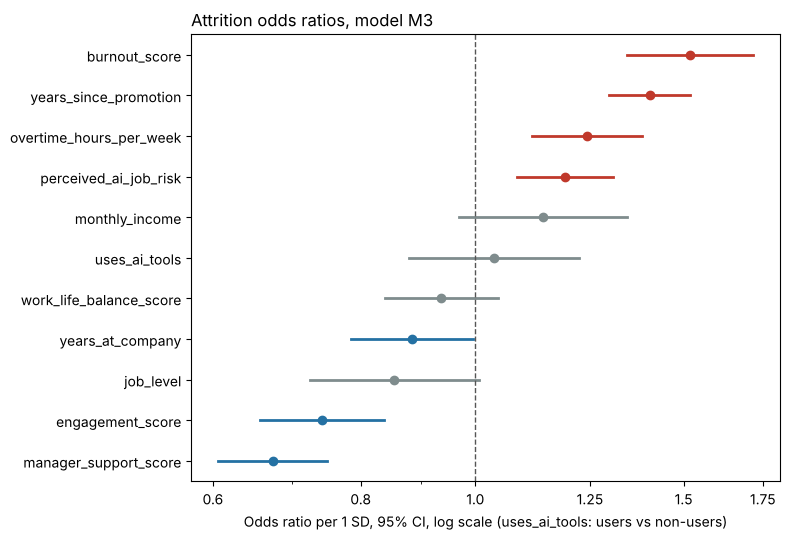

In [30]:
# Forest plot for the individual-level predictors (department and work mode shown in the table)
plot_vars = [v for v in WELLBEING + CAREER + AI_VARS]
fp = or_tbl.loc[plot_vars].sort_values("odds_ratio")

fig, ax = plt.subplots(figsize=(8, 5.5))
# Red = CI above 1 (higher attrition odds), blue = CI below 1, grey = CI includes 1
for i, (or_, lo, hi) in enumerate(zip(fp.odds_ratio, fp.ci_low, fp.ci_high)):
    color = "#c0392b" if lo > 1 else "#2471a3" if hi < 1 else "#7f8c8d"
    ax.plot([lo, hi], [i, i], color=color, linewidth=2)
    ax.scatter(or_, i, color=color, zorder=3)
ax.axvline(1, color="#555555", linewidth=1, linestyle="--")
ax.set_xscale("log")
ax.set_xticks([0.6, 0.8, 1.0, 1.25, 1.5, 1.75])
ax.set_xticklabels(["0.6", "0.8", "1.0", "1.25", "1.5", "1.75"])
ax.set_yticks(range(len(fp)))
ax.set_yticklabels(fp.index)
ax.set_xlabel("Odds ratio per 1 SD, 95% CI, log scale (uses_ai_tools: users vs non-users)")
ax.set_title("Attrition odds ratios, model M3", loc="left")
plt.tight_layout()
plt.show()

In [31]:
# Department odds ratios before and after adjusting for individual-level factors
dept_term = "C(department, Treatment('Customer Support'))"
m_dept_only = smf.logit(f"left ~ {dept_term}", data=mdf).fit(disp=0)
dept_terms = [t for t in m3.params.index if t.startswith(dept_term)]
dept_cmp = pd.DataFrame({
    "unadjusted_OR": np.exp(m_dept_only.params[dept_terms]),
    "unadjusted_p": m_dept_only.pvalues[dept_terms],
    "adjusted_OR_M3": np.exp(m3.params[dept_terms]),
    "adjusted_p_M3": m3.pvalues[dept_terms],
})
dept_cmp.index = dept_cmp.index.str.extract(r"\[T\.(.+)\]")[0].values
dept_cmp["mean_burnout"] = df.groupby("department")["burnout_score"].mean().reindex(dept_cmp.index)
print("Reference: Customer Support, mean burnout", round(df.loc[df.department == "Customer Support", "burnout_score"].mean(), 2))
dept_cmp.round(3)

Reference: Customer Support, mean burnout 4.37


,unadjusted_OR,unadjusted_p,adjusted_OR_M3,adjusted_p_M3,mean_burnout
Engineering,0.536,0.000,0.670,0.025,3.784
Finance,0.699,0.021,0.774,0.165,3.958
Human Resources,0.695,0.056,0.843,0.433,3.944
Marketing,0.734,0.043,0.789,0.182,4.070
Operations,0.656,0.002,0.780,0.124,3.986
Research & Development,0.552,0.000,0.719,0.120,3.764
Sales,0.789,0.062,0.707,0.025,4.394


Holding the other factors constant:

- **Burnout** has the largest positive association: each 1 SD increase (about 1.5 points) multiplies the odds of leaving by 1.52.
- **Years since promotion** is the second largest (OR 1.40 per 1.6 years), so the gradient seen in Section 5.4 is not explained by wellbeing or job differences.
- **Manager support** is the strongest protective factor (OR 0.67 per 1.8 points), ahead of engagement (OR 0.74). In Section 3, engagement had the larger Cohen's d, but engagement and manager support are correlated (r = 0.63). Once both are in the model, part of engagement's raw gap turns out to be shared with manager support.
- **Overtime** remains associated with higher odds (OR 1.24 per 4.5 hours a week).
- **Perceived AI job risk** has an OR of 1.19 per 1.8 points (95% CI 1.09 to 1.31): clearly above 1, but smaller than burnout, promotion timing or manager support. **Using AI tools** has no association (OR 1.04, CI includes 1).
- **Work-life balance, monthly income and job level** are not significant at the 5% level once the other factors are included. Tenure has a small protective association (OR 0.88, p = 0.04).
- **Most department gaps shrink once individual factors are controlled** (table above). Unadjusted, five of seven departments have significantly lower odds than Customer Support. After adjustment, most odds ratios move toward 1 (Engineering from 0.54 to 0.67, R&D from 0.55 to 0.72), and only Engineering and Sales remain significant. Part of Customer Support's higher raw attrition therefore reflects the individual conditions of its employees, such as higher burnout and perceived AI risk. Sales is the exception: its odds ratio moves slightly away from 1 (0.79 to 0.71), because its employees already report burnout as high as Customer Support's, so controlling for burnout does not explain its gap.
- **Onsite work** has modestly higher odds than hybrid (OR 1.20, p = 0.046); remote work is not different from hybrid after adjustment.

These are associations in cross-sectional data, not causal effects. Wellbeing scores are measured at the same time as attrition status, so some of the association may run in the other direction: employees who have already decided to leave may also report lower engagement.

### 6.4 Correlation among wellbeing predictors

Wellbeing scores are often correlated, which can make individual coefficients unstable. The correlation matrix and variance inflation factors (VIF) show how much overlap there is.

In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("Correlation among wellbeing and AI-risk scores:")
display(df[WELLBEING + ["perceived_ai_job_risk"]].corr().round(2))

X_vif = mdf[CONTINUOUS].assign(const=1.0)
vif = pd.Series([variance_inflation_factor(X_vif.values, i) for i in range(len(CONTINUOUS))],
                index=CONTINUOUS, name="VIF").sort_values(ascending=False)
vif.round(2)

Correlation among wellbeing and AI-risk scores:


,burnout_score,engagement_score,manager_support_score,work_life_balance_score,overtime_hours_per_week,perceived_ai_job_risk
burnout_score,1.00,-0.55,-0.31,-0.59,0.56,0.14
engagement_score,-0.55,1.00,0.63,0.27,-0.21,-0.07
manager_support_score,-0.31,0.63,1.00,0.08,0.01,0.02
work_life_balance_score,-0.59,0.27,0.08,1.00,-0.63,-0.07
overtime_hours_per_week,0.56,-0.21,0.01,-0.63,1.00,0.03
perceived_ai_job_risk,0.14,-0.07,0.02,-0.07,0.03,1.00


job_level                  3.27
monthly_income             2.73
burnout_score              2.35
engagement_score           2.30
years_at_company           2.13
overtime_hours_per_week    1.91
work_life_balance_score    1.90
manager_support_score      1.77
perceived_ai_job_risk      1.13
years_since_promotion      1.11
Name: VIF, dtype: float64

All VIFs are below 3.3, so multicollinearity is moderate rather than severe. Two overlaps still shape the interpretation:

- **Work-life balance** is correlated with burnout (r = -0.59) and overtime (r = -0.63). Its non-significant odds ratio means it adds little information once burnout and overtime are known, not that work-life balance is unimportant.
- **Job level and monthly income** have the highest VIFs (3.3 and 2.7), consistent with pay rising with level. Their shared variation is one reason neither is individually significant.

### 6.5 Department or job role?

Job roles are nested within departments, so job role is the more detailed grouping. M3 is refitted with job role in place of department. Because every department is a combination of its roles, M3 is nested in the job-role model and an LR test applies.

In [33]:
F3_role = F3.replace("C(department, Treatment('Customer Support'))", "C(job_role)")
m3_role = smf.logit(f"left ~ {F3_role}", data=mdf).fit(disp=0)
stat, d, p = lr_test(m3, m3_role)

pd.DataFrame({
    "parameters": [int(m3.df_model), int(m3_role.df_model)],
    "AIC": [m3.aic, m3_role.aic],
    "BIC": [m3.bic, m3_role.bic],
    "AI_risk_OR": [np.exp(m3.params["perceived_ai_job_risk"]), np.exp(m3_role.params["perceived_ai_job_risk"])],
    "AI_risk_p": [m3.pvalues["perceived_ai_job_risk"], m3_role.pvalues["perceived_ai_job_risk"]],
}, index=["M3 (department)", "M3 (job role)"]).round(4).assign(
    LR_vs_department=["", f"stat={stat:.1f}, df={d}, p={p:.3f}"])

,parameters,AIC,BIC,AI_risk_OR,AI_risk_p,LR_vs_department
M3 (department),20,3959.7925,4096.6535,1.1914,0.0002,
M3 (job role),37,3970.0273,4217.6806,1.1980,0.0002,"stat=23.8, df=17, p=0.126"


Replacing department with job role adds 17 parameters without a significant improvement in fit (LR p = 0.126), and both AIC and BIC are worse. Department captures the useful grouping, so M3 keeps department. The AI-risk odds ratio barely moves (1.19 to 1.20), so its association is not explained by finer differences between roles.

### 6.6 Does compensation offset promotion stagnation?

Section 5.6 compared high- and low-income employees within the 4+ years-since-promotion group and found nearly identical attrition rates. That comparison used one subgroup and a median split. An interaction term tests the same idea across all employees: if higher income weakened the link between promotion stagnation and attrition, the `years_since_promotion:monthly_income` odds ratio would be below 1 and significant.

In [34]:
m3_int = smf.logit(f"left ~ {F3} + years_since_promotion:monthly_income", data=mdf).fit(disp=0)
term = "years_since_promotion:monthly_income"
lo, hi = np.exp(m3_int.conf_int().loc[term])
print(f"Interaction OR = {np.exp(m3_int.params[term]):.3f} (95% CI {lo:.3f} to {hi:.3f}), p = {m3_int.pvalues[term]:.3f}")
stat, d, p = lr_test(m3, m3_int)
print(f"LR test vs M3: stat = {stat:.2f}, df = {d}, p = {p:.3f}")

Interaction OR = 1.061 (95% CI 0.982 to 1.146), p = 0.134
LR test vs M3: stat = 2.24, df = 1, p = 0.135


The interaction is not significant (OR 1.06, 95% CI 0.98 to 1.15, p = 0.13), and its point estimate is above 1 rather than below. There is no evidence that higher pay weakens the association between promotion stagnation and attrition, which is consistent with the subgroup result in Section 5.6. A non-significant interaction is not proof that no offset exists, but this dataset gives no support for using pay alone as a retention lever for employees who have not been promoted.

## 7. Out-of-Sample Risk Scoring and Retention Prioritization

Section 6 explains which factors are associated with attrition. This section asks a practical question: if HR can only hold retention conversations with a limited share of employees, **how well does a risk score rank the people who will actually leave?**

The score uses the same predictors as M3. It is evaluated only on employees the model did not see during fitting.

### 7.1 Why cross-validation instead of a single train/test split

With 895 leavers, a 20% test set contains only about 179 positive cases, so metrics from one split depend noticeably on which employees happen to land in it. The cell below repeats a single 80/20 split with 20 different random seeds to show that variation.

In [35]:
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

SCORE_NUM = WELLBEING + CAREER + ["perceived_ai_job_risk", "uses_ai_tools"]
SCORE_CAT = ["department", "work_mode"]

X_score = df[[c for c in SCORE_NUM if c != "uses_ai_tools"] + SCORE_CAT].copy()
X_score["uses_ai_tools"] = df["uses_ai_tools_at_work"].astype(int)
y_score = (df["attrition"] == "Yes").astype(int)

# Same specification as M3, unpenalized so it matches the statsmodels fit
score_model = make_pipeline(
    make_column_transformer(
        (StandardScaler(), SCORE_NUM),
        (OneHotEncoder(drop="first"), SCORE_CAT),
    ),
    LogisticRegression(C=np.inf, max_iter=5000),
)

def top_k_metrics(y_true, prob, k):
    # Share of all leavers captured in the top k fraction, and lift over the base rate
    n = int(round(len(prob) * k))
    top = np.argsort(-prob)[:n]
    captured = y_true[top].sum()
    return captured / y_true.sum(), y_true[top].mean() / y_true.mean()

split_rows = []
for seed in range(20):
    X_tr, X_te, y_tr, y_te = train_test_split(X_score, y_score, test_size=0.2, stratify=y_score, random_state=seed)
    p = score_model.fit(X_tr, y_tr).predict_proba(X_te)[:, 1]
    recall10, lift10 = top_k_metrics(y_te.values, p, 0.10)
    split_rows.append({"ROC_AUC": roc_auc_score(y_te, p), "PR_AUC": average_precision_score(y_te, p),
                       "Recall@10%": recall10, "Lift@10%": lift10})

pd.DataFrame(split_rows).describe().loc[["min", "50%", "max"]].round(3)

,ROC_AUC,PR_AUC,Recall@10%,Lift@10%
min,0.752,0.400,0.263,2.626
50%,0.775,0.440,0.293,2.933
max,0.799,0.476,0.324,3.240


Across 20 random splits, test ROC-AUC ranges from 0.752 to 0.799 and Lift@10% from 2.63 to 3.24. A single split could report any value in these ranges, so the evaluation below uses cross-validation instead.

### 7.2 Out-of-fold risk scores

Stratified 5-fold cross-validation fits the model five times, each time on 80% of employees, and scores the held-out 20%. Every employee ends up with exactly one **out-of-fold** probability from a model that never saw them. All ranking and calibration results below use these 5,000 out-of-fold scores.

Metrics:
- **ROC-AUC:** probability that a random leaver is ranked above a random stayer.
- **PR-AUC:** average precision across thresholds; the no-skill baseline equals the attrition rate (0.179).
- **Brier score:** mean squared error of the predicted probabilities; compared with a constant prediction equal to the base rate.

In [36]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_prob = cross_val_predict(score_model, X_score, y_score, cv=cv, method="predict_proba")[:, 1]
y_arr = y_score.values
base_rate = y_arr.mean()

pd.Series({
    "ROC_AUC": roc_auc_score(y_arr, oof_prob),
    "PR_AUC": average_precision_score(y_arr, oof_prob),
    "PR_AUC_no_skill": base_rate,
    "Brier": brier_score_loss(y_arr, oof_prob),
    "Brier_constant_base_rate": brier_score_loss(y_arr, np.full_like(oof_prob, base_rate)),
}).round(4)

ROC_AUC                     0.7734
PR_AUC                      0.4296
PR_AUC_no_skill             0.1790
Brier                       0.1251
Brier_constant_base_rate    0.1470
dtype: float64

### 7.3 Calibration

A ranking can be useful even if its probabilities are off, but if HR reads a score of 0.40 as "40% likely to leave", the probabilities need to be calibrated. Employees are grouped into ten bins by predicted probability, and the average prediction in each bin is compared with the observed attrition rate. Points on the diagonal indicate good calibration.

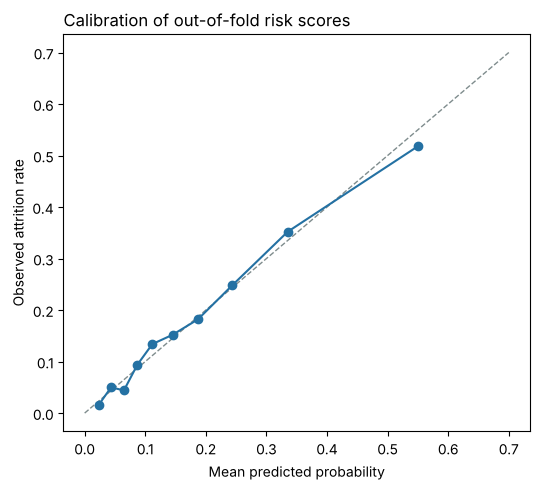

,mean_predicted,observed_rate,n
bin,,,
0,0.023,0.016,500
1,0.044,0.050,500
2,0.065,0.044,500
3,0.087,0.094,500
4,0.112,0.134,500
5,0.145,0.152,500
6,0.187,0.182,500
7,0.244,0.248,500
8,0.335,0.352,500


In [37]:
calib = pd.DataFrame({"prob": oof_prob, "left": y_arr})
calib["bin"] = pd.qcut(calib["prob"], 10, labels=False)
calib_tbl = calib.groupby("bin").agg(mean_predicted=("prob", "mean"), observed_rate=("left", "mean"), n=("left", "size"))

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 0.7], [0, 0.7], linestyle="--", color="#7f8c8d", linewidth=1)
ax.plot(calib_tbl.mean_predicted, calib_tbl.observed_rate, marker="o", color="#2471a3")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed attrition rate")
ax.set_title("Calibration of out-of-fold risk scores", loc="left")
plt.tight_layout()
plt.show()

calib_tbl.round(3)

Predicted and observed attrition rates are close in every bin. In the highest-risk bin, the model predicts 55.0% and 51.8% actually left. The model was fitted without class reweighting. Reweighting toward the minority class would mainly shift every probability upward, making the scores harder to read as likelihoods. The Brier score (0.125) is also lower than that of a constant base-rate prediction (0.147).

### 7.4 Risk deciles, lift and recall

Employees are sorted by out-of-fold risk and split into ten equal groups. For each decile the table shows the attrition rate, the **lift** (decile rate divided by the 17.9% base rate) and the **cumulative recall** (share of all leavers captured when HR works down the list to that decile).

Recall and lift at 10% and 20% coverage are reported with bootstrap 95% confidence intervals, resampling employees 1,000 times.

In [38]:
dec = pd.DataFrame({"prob": oof_prob, "left": y_arr})
# Decile 1 = highest predicted risk
dec["risk_decile"] = pd.qcut(-dec["prob"].rank(method="first"), 10, labels=range(1, 11)).astype(int)
dec_tbl = dec.groupby("risk_decile").agg(n=("left", "size"), leavers=("left", "sum"),
                                         attrition_rate=("left", "mean"), mean_score=("prob", "mean"))
dec_tbl["lift"] = dec_tbl["attrition_rate"] / base_rate
dec_tbl["cumulative_recall"] = dec_tbl["leavers"].cumsum() / y_arr.sum()
dec_tbl.round(3)

,n,leavers,attrition_rate,mean_score,lift,cumulative_recall
risk_decile,,,,,,
1,500,259,0.518,0.550,2.894,0.289
2,500,176,0.352,0.335,1.966,0.486
3,500,124,0.248,0.244,1.385,0.625
4,500,91,0.182,0.187,1.017,0.726
5,500,76,0.152,0.145,0.849,0.811
6,500,67,0.134,0.112,0.749,0.886
7,500,47,0.094,0.087,0.525,0.939
8,500,22,0.044,0.065,0.246,0.963
9,500,25,0.050,0.044,0.279,0.991


In [39]:
rng = np.random.default_rng(42)
boot = {k: [] for k in ["Recall@10%", "Lift@10%", "Recall@20%", "Lift@20%"]}
for _ in range(1000):
    idx = rng.integers(0, len(y_arr), len(y_arr))
    for k in [0.10, 0.20]:
        r, l = top_k_metrics(y_arr[idx], oof_prob[idx], k)
        boot[f"Recall@{int(k*100)}%"].append(r)
        boot[f"Lift@{int(k*100)}%"].append(l)

point = {}
for k in [0.10, 0.20]:
    r, l = top_k_metrics(y_arr, oof_prob, k)
    point[f"Recall@{int(k*100)}%"], point[f"Lift@{int(k*100)}%"] = r, l

pd.DataFrame({
    "estimate": point,
    "ci_low": {k: np.percentile(v, 2.5) for k, v in boot.items()},
    "ci_high": {k: np.percentile(v, 97.5) for k, v in boot.items()},
}).round(3)

,estimate,ci_low,ci_high
Recall@10%,0.289,0.266,0.314
Lift@10%,2.894,2.664,3.138
Recall@20%,0.486,0.456,0.512
Lift@20%,2.430,2.281,2.562


- The **top decile** has an attrition rate of 51.8%, **2.9 times** the base rate, and contains **28.9%** of all leavers (95% CI 26.6% to 31.4%).
- The **top 20%** of the ranking contains **48.6%** of leavers (95% CI 45.6% to 51.2%), a lift of 2.4.
- The bottom decile has an attrition rate of only 1.6%.

The score concentrates leavers effectively, but about half of all leavers still sit outside the top 20%. With a ROC-AUC of 0.77, it is a tool for **prioritizing** retention effort, not for predicting whether a specific employee will leave.

### 7.5 Comparison with a rule-based watch list

A simpler alternative is a rule-based watch list built from median cut-offs. Three flags are defined:
- high burnout **and** low engagement,
- high perceived AI job risk,
- high overtime **and** low manager support.

Employees who trigger all three flags form the rule-based list. To compare fairly, the model's list is set to the **same number of employees**, taken from the top of the out-of-fold ranking.

In [40]:
burnout_med = df["burnout_score"].median()
engagement_med = df["engagement_score"].median()
ai_risk_med = df["perceived_ai_job_risk"].median()
overtime_med = df["overtime_hours_per_week"].median()
support_med = df["manager_support_score"].median()

flag_burnout_engagement = (df["burnout_score"] >= burnout_med) & (df["engagement_score"] <= engagement_med)
flag_ai_risk = df["perceived_ai_job_risk"] >= ai_risk_med
flag_overtime_support = (df["overtime_hours_per_week"] >= overtime_med) & (df["manager_support_score"] <= support_med)
risk_flag_count = flag_burnout_engagement.astype(int) + flag_ai_risk.astype(int) + flag_overtime_support.astype(int)

print("Employees by number of flags triggered:")
print(risk_flag_count.value_counts().sort_index().to_string())

rule_list = (risk_flag_count == 3).values
n_list = rule_list.sum()
model_list = np.zeros(len(y_arr), dtype=bool)
model_list[np.argsort(-oof_prob)[:n_list]] = True

comparison = pd.DataFrame({
    "employees_on_list": [n_list, n_list],
    "share_of_workforce": [n_list / len(y_arr)] * 2,
    "leavers_on_list": [y_arr[rule_list].sum(), y_arr[model_list].sum()],
    "precision": [y_arr[rule_list].mean(), y_arr[model_list].mean()],
    "recall": [y_arr[rule_list].sum() / y_arr.sum(), y_arr[model_list].sum() / y_arr.sum()],
    "ROC_AUC_of_full_ranking": [roc_auc_score(y_arr, risk_flag_count), roc_auc_score(y_arr, oof_prob)],
}, index=["Rule: all 3 flags", "Model: top-ranked"])
comparison.round(3)

Employees by number of flags triggered:
0    1471
1    1954
2    1117
3     458


,employees_on_list,share_of_workforce,leavers_on_list,precision,recall,ROC_AUC_of_full_ranking
Rule: all 3 flags,458,0.092,195,0.426,0.218,0.698
Model: top-ranked,458,0.092,242,0.528,0.270,0.773


At the same list size (458 employees, 9.2% of the workforce), the model's list contains **242 leavers versus 195** for the rule-based list: precision rises from 42.6% to 52.8% and recall from 21.8% to 27.0%. With the same number of retention conversations, HR would reach 47 more employees who actually left. The full model ranking also has a higher ROC-AUC (0.773 vs 0.698 for the flag count).

The rule underperforms for three reasons visible in Section 6: it reduces each score to above or below the median, it gives the AI-risk flag the same weight as burnout and engagement even though its odds ratio is much smaller, and it leaves out promotion timing, the second-strongest factor.

### 7.6 Where the highest-risk employees concentrate

Using the model's top 10% as the watch list, the tables show what share of each department and job role falls on the list. A department with 10% of its staff on the list is at the company average.

In [41]:
watch = df[["department", "job_role", "work_mode"]].copy()
watch["on_watch_list"] = dec["risk_decile"].values == 1
watch["left"] = y_arr

def concentration(col):
    t = watch.groupby(col).agg(headcount=("on_watch_list", "size"), on_list=("on_watch_list", "sum"),
                              attrition_rate=("left", "mean"))
    t["share_on_list"] = t["on_list"] / t["headcount"]
    return t.sort_values("share_on_list", ascending=False)

print("By department:")
display(concentration("department").round(3))
print("By work mode:")
display(concentration("work_mode").round(3))
print("Top 10 job roles:")
concentration("job_role").head(10).round(3)

By department:


,headcount,on_list,attrition_rate,share_on_list
department,,,,
Customer Support,636,114,0.241,0.179
Sales,835,99,0.200,0.119
Human Resources,244,28,0.180,0.115
Marketing,440,47,0.189,0.107
Operations,663,62,0.172,0.094
Finance,436,39,0.181,0.089
Engineering,1336,88,0.145,0.066
Research & Development,410,23,0.149,0.056


By work mode:


,headcount,on_list,attrition_rate,share_on_list
work_mode,,,,
Onsite,1742,249,0.212,0.143
Hybrid,2237,181,0.168,0.081
Remote,1021,70,0.147,0.069


Top 10 job roles:


,headcount,on_list,attrition_rate,share_on_list
job_role,,,,
Support Specialist,218,41,0.252,0.188
Customer Success Manager,214,39,0.210,0.182
Support Team Lead,204,34,0.260,0.167
HR Manager,94,13,0.170,0.138
Account Executive,277,36,0.238,0.130
Recruiter,69,8,0.232,0.116
Content Strategist,138,16,0.239,0.116
Sales Manager,299,34,0.164,0.114
Sales Development Rep,259,29,0.201,0.112


- **Customer Support** has 17.9% of its employees on the watch list, about 1.8 times the company average, followed by **Sales** (11.9%). Engineering (6.6%) and R&D (5.6%) are well below average.
- **Onsite** employees are twice as likely as remote employees to be on the list (14.3% vs 6.9%).
- The roles with the highest concentration are **Support Specialist (18.8%)**, **Customer Success Manager (18.2%)** and **Support Team Lead (16.7%)**. HR Manager (94 employees) and Recruiter (69) appear in the top ten but have small headcounts, so their shares are less reliable.

The model-based list confirms the customer-facing concentration found in Section 2, using a ranking that is validated out of sample.

## 8. Key Findings and Recommendations

### Key findings
1. **Burnout, low manager support and promotion stagnation are the strongest factors** associated with attrition in the joint model (odds ratios 1.52, 0.67 and 1.40 per SD). Engagement and overtime also remain significant.
2. **Perceived AI job risk is a real but secondary factor.** It stays significant after controlling for wellbeing, career factors, department and work mode (OR 1.19 per SD), but it improves model fit only slightly. Actual AI tool usage shows no association.
3. **Pay does not offset promotion stagnation.** Both the subgroup comparison and the interaction test find no evidence that higher income weakens the stagnation association.
4. **Department gaps partly reflect individual conditions.** Once burnout, AI risk and other factors are controlled, most departments' gaps with Customer Support move toward zero and only Engineering and Sales remain significantly lower.
5. **A simple logistic risk score ranks leavers well enough to guide prioritization.** Out of sample, the top 10% of employees by risk contains 29% of leavers (lift 2.9), and the top 20% contains 49%. Probabilities are well calibrated.
6. **The model outperforms a median-flag rule.** At the same list size, it reaches 24% more actual leavers (242 vs 195).

### Recommendations
- **Use the risk ranking to order retention conversations,** starting with the top decile and extending to the top 20% where capacity allows. Treat the score as a prioritization aid for managers and HR partners, not as a label on individual employees.
- **Review promotion pathways** for employees two or more years past their last promotion, and pair any compensation action with a concrete advancement plan.
- **Invest in manager support** in the teams with the highest concentration of risk, since it is the strongest protective factor in the model.
- **Address workload and burnout in Customer Support and Sales,** where risk concentrates and onsite work is common.
- **Keep AI-transition communication and reskilling in proportion.** Perceived AI risk matters, but less than burnout, manager support or promotion timing.

### Limitations
- **Associations, not causal effects.** The data are a single cross-sectional snapshot, and wellbeing scores may partly reflect a decision to leave that has already been made.
- **Moderate discrimination.** A ROC-AUC of 0.77 is useful for ranking groups of employees but leaves many leavers outside any short list.
- **Fairness review before use.** Protected characteristics are excluded from the score, but other predictors may still correlate with them. Any operational use should audit the watch list by demographic group and keep a human decision-maker in the loop.
- **Data provenance.** The dataset was provided as part of the course materials and its original generation process is not documented, so the results describe this dataset rather than a verified organization.